# Sentiment Analysis using BERT — IMDb Movie Reviews

**Case Study:** Sentiment Analysis using BERT  
**Dataset:** IMDb Large Movie Review Dataset (ACL IMDb folder)

In [1]:
# # If required, install the libraries.
# # Run this cell once.

# !pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib seaborn torch

In [2]:
# pip install tf-keras

In [3]:
# ============================================================
# BERT IMDb SENTIMENT ANALYSIS - INSTALL REQUIRED LIBRARIES
# ============================================================

import sys
import subprocess
import importlib.util

# Packages required by this notebook
packages = {
    "torch": "torch",
    "transformers": "transformers",
    "accelerate": "accelerate>=0.26.0",
    "datasets": "datasets",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "jupyter": "jupyter"
}

print("Checking required packages...\n")

for module, package in packages.items():

    if importlib.util.find_spec(module) is None:
        print(f"❌ {module} not found → Installing {package} ...")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            package
        ])

        print(f"✅ {module} installed.\n")

    else:
        print(f"✅ {module} already installed.")

print("\n" + "=" * 60)
print("INSTALLATION CHECK COMPLETED")
print("=" * 60)

print("\n⚠️ IMPORTANT:")
print("If packages were installed/updated, restart the Jupyter kernel")
print("before running the remaining notebook cells.")

Checking required packages...

✅ torch already installed.
✅ transformers already installed.
✅ accelerate already installed.
✅ datasets already installed.
✅ sklearn already installed.
✅ pandas already installed.
✅ numpy already installed.
✅ matplotlib already installed.
✅ seaborn already installed.
✅ jupyter already installed.

INSTALLATION CHECK COMPLETED

⚠️ IMPORTANT:
If packages were installed/updated, restart the Jupyter kernel
before running the remaining notebook cells.


In [4]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("Transformers imported successfully!")


Transformers imported successfully!


## 1. Import Libraries

In [5]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.7.1+cpu
CUDA available: False


## 2. Set Dataset Path

The code first checks whether the `acllmdb` folder is in the current working directory.

If your folder is somewhere else, change `DATA_DIR` manually.

Examples:

```python
DATA_DIR = "./acllmdb"
```

or on Windows:

```python
DATA_DIR = r"C:\Users\YourName\Downloads\acllmdb"
```

In [6]:
# Dataset is already the current working directory
DATA_DIR = "."

print("Current working directory:", os.getcwd())
print("Dataset path:", os.path.abspath(DATA_DIR))
print("Dataset exists:", os.path.exists(DATA_DIR))

print("\nTrain folder exists:", os.path.exists(os.path.join(DATA_DIR, "train")))
print("Test folder exists:", os.path.exists(os.path.join(DATA_DIR, "test")))

assert os.path.exists(os.path.join(DATA_DIR, "train")), "train folder not found!"
assert os.path.exists(os.path.join(DATA_DIR, "test")), "test folder not found!"

print("\n✅ IMDb dataset found successfully!")

Current working directory: c:\Users\aryan\Downloads\aclImdb_v1\aclImdb
Dataset path: c:\Users\aryan\Downloads\aclImdb_v1\aclImdb
Dataset exists: True

Train folder exists: True
Test folder exists: True

✅ IMDb dataset found successfully!


## 3. Read IMDb Reviews

Each `.txt` file contains one movie review.

- `pos` → positive sentiment → label `1`
- `neg` → negative sentiment → label `0`

In [7]:
def load_reviews(folder, label):
    rows = []

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")

    for filename in os.listdir(folder):
        if filename.endswith(".txt"):
            filepath = os.path.join(folder, filename)

            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    text = f.read().strip()
            except UnicodeDecodeError:
                with open(filepath, "r", encoding="latin-1") as f:
                    text = f.read().strip()

            rows.append({
                "review": text,
                "label": label
            })

    return rows


train_pos = load_reviews(os.path.join(DATA_DIR, "train", "pos"), 1)
train_neg = load_reviews(os.path.join(DATA_DIR, "train", "neg"), 0)

test_pos = load_reviews(os.path.join(DATA_DIR, "test", "pos"), 1)
test_neg = load_reviews(os.path.join(DATA_DIR, "test", "neg"), 0)

train_data = train_pos + train_neg
test_data = test_pos + test_neg

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

# Shuffle the rows
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Training samples:", len(train_df))
print("Testing samples :", len(test_df))
print("\nTraining label distribution:")
print(train_df["label"].value_counts())

Training samples: 25000
Testing samples : 25000

Training label distribution:
label
1    12500
0    12500
Name: count, dtype: int64


In [8]:
# Display sample reviews
display(train_df.head())

print("\nPositive review example:")
print(train_df[train_df["label"] == 1]["review"].iloc[0][:1000])

print("\nNegative review example:")
print(train_df[train_df["label"] == 0]["review"].iloc[0][:1000])

,review,label
0,In Panic In The Streets Richard Widmark plays ...,1
1,If you ask me the first one was really better ...,0
2,I am a big fan a Faerie Tale Theatre and I've ...,1
3,I just finished reading a book about Dillinger...,0
4,Greg Davis and Bryan Daly take some crazed sta...,0



Positive review example:
In Panic In The Streets Richard Widmark plays U.S. Navy doctor who has his week rudely interrupted with a corpse that contains plague. As cop Paul Douglas properly points out the guy died from two bullets in the chest. That's not the issue here, the two of them become unwilling partners in an effort to find the killers and anyone else exposed to the disease.<br /><br />As was pointed out by any number of people, for some reason director Elia Kazan did not bother to cast the small parts with anyone that sounds like they're from Louisiana. Having been to New Orleans where the story takes place I can personally attest to that. Richard Widmark and his wife Barbara Bel Geddes can be excused because as a Navy doctor he could be assigned there, but for those that are natives it doesn't work.<br /><br />But with plague out there and the news being kept a secret, the New Orleans PD starts a dragnet of the city's underworld. The dead guy came off a ship from Europe and 

## 4. Basic Data Exploration

In [9]:
print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nDuplicate reviews:", train_df["review"].duplicated().sum())

train_df["review_length"] = train_df["review"].str.len()

print("\nReview length statistics:")
print(train_df["review_length"].describe())

Training shape: (25000, 2)
Testing shape : (25000, 2)

Missing values:
review    0
label     0
dtype: int64

Duplicate reviews: 96

Review length statistics:
count    25000.000000
mean      1325.068600
std       1003.132835
min         52.000000
25%        702.000000
50%        979.000000
75%       1614.000000
max      13704.000000
Name: review_length, dtype: float64


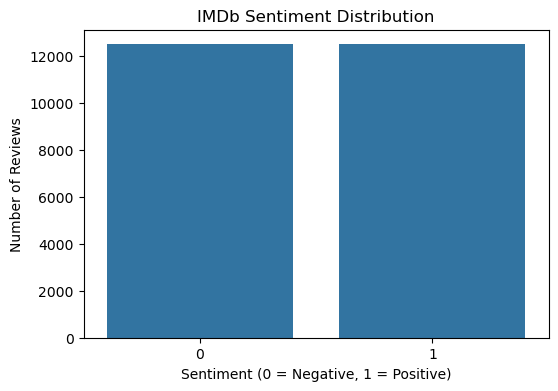

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="label")
plt.title("IMDb Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Reviews")
plt.show()

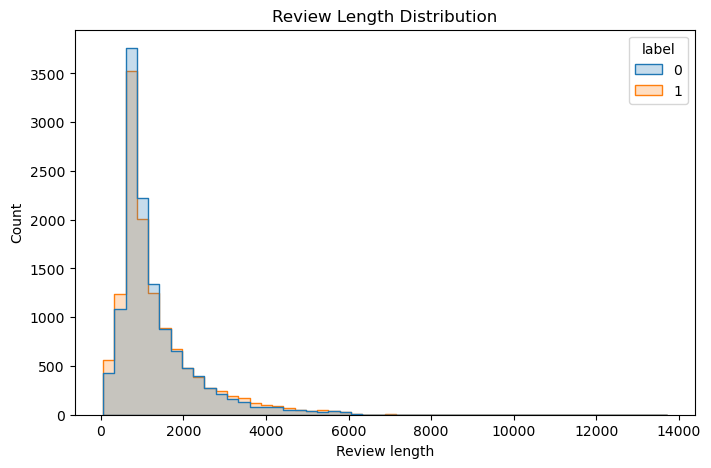

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=train_df,
    x="review_length",
    hue="label",
    bins=50,
    element="step"
)
plt.title("Review Length Distribution")
plt.xlabel("Review length")
plt.show()

## 5. Prepare the Data

BERT performs its own tokenization, so we should **not** use TF-IDF, Bag-of-Words, LabelEncoder, or StandardScaler for the review text.

We only need:

- review text
- sentiment label

In [12]:
# Remove empty reviews if any.
# This does NOT remove normal rows; it only removes rows with no usable text.
train_df = train_df[train_df["review"].str.strip().ne("")].reset_index(drop=True)
test_df = test_df[test_df["review"].str.strip().ne("")].reset_index(drop=True)

# Keep only required columns
train_df = train_df[["review", "label"]]
test_df = test_df[["review", "label"]]

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

Training shape: (25000, 2)
Testing shape : (25000, 2)


## 6. Create Validation Set

The official IMDb test set is kept untouched for final evaluation.

We split the official training set into:

- 90% training
- 10% validation

In [13]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["review"].tolist(),
    train_df["label"].tolist(),
    test_size=0.10,
    random_state=42,
    stratify=train_df["label"]
)

test_texts = test_df["review"].tolist()
test_labels = test_df["label"].tolist()

print("Training:", len(train_texts))
print("Validation:", len(val_texts))
print("Testing:", len(test_texts))

Training: 22500
Validation: 2500
Testing: 25000


## 7. Optional Dataset Size Control

Full IMDb training contains 25,000 labeled reviews.

**For the final assignment, keep these as `None`** if you have a GPU and enough time.

If you are running on a CPU and only want to test whether the notebook works, temporarily use values such as:

```python
MAX_TRAIN_SAMPLES = 3000
MAX_VAL_SAMPLES = 500
MAX_TEST_SAMPLES = 1000
```

After confirming that everything works, set them back to `None` for the complete experiment.

In [14]:
MAX_TRAIN_SAMPLES = 2000
MAX_VAL_SAMPLES = 300
MAX_TEST_SAMPLES = 500

def limit_data(texts, labels, max_samples, seed=42):
    if max_samples is None or max_samples >= len(texts):
        return texts, labels

    rng = np.random.default_rng(seed)
    indices = rng.choice(len(texts), size=max_samples, replace=False)
    indices = sorted(indices)

    return [texts[i] for i in indices], [labels[i] for i in indices]

train_texts, train_labels = limit_data(
    train_texts, train_labels, MAX_TRAIN_SAMPLES
)

val_texts, val_labels = limit_data(
    val_texts, val_labels, MAX_VAL_SAMPLES
)

test_texts, test_labels = limit_data(
    test_texts, test_labels, MAX_TEST_SAMPLES
)

print("Final training samples:", len(train_texts))
print("Final validation samples:", len(val_texts))
print("Final test samples:", len(test_texts))

Final training samples: 2000
Final validation samples: 300
Final test samples: 500


## 8. Load Pretrained BERT Tokenizer

We use:

**`bert-base-uncased`**

BERT converts text into tokens and then into numerical IDs that can be processed by the neural network.

In [15]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully.")
print("Vocabulary size:", tokenizer.vocab_size)

Tokenizer loaded successfully.
Vocabulary size: 30522


## 9. Tokenize the Reviews

`max_length=256` limits each review to 256 tokens.

Longer reviews are truncated and shorter reviews are padded when required.

In [16]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item


MAX_LENGTH = 128

train_dataset = IMDbDataset(
    train_texts, train_labels, tokenizer, MAX_LENGTH
)

val_dataset = IMDbDataset(
    val_texts, val_labels, tokenizer, MAX_LENGTH
)

test_dataset = IMDbDataset(
    test_texts, test_labels, tokenizer, MAX_LENGTH
)

print("Dataset objects created successfully.")

Dataset objects created successfully.


In [17]:
# See how BERT tokenizes one review
sample_text = train_texts[0]

tokens = tokenizer.tokenize(sample_text[:500])
token_ids = tokenizer.encode(
    sample_text[:500],
    truncation=True,
    max_length=20
)

print("Original text:")
print(sample_text[:500])

print("\nFirst tokens:")
print(tokens[:30])

print("\nToken IDs:")
print(token_ids)

Original text:
This review comes nearly 30 years late. Nevertheless, it has to be mentioned that I chanced by a copy of this movie sometime in early 2008 and watched it repeatedly for 4 months straight! I just had to write about it! I got smitten and forgot anything else existed once I saw this movie. How ironic it is to see Literature's ugliest male protagonist portrayed by the handsomest man! yet, what a welcome irony! It suited me perfectly and more so because Timothy Dalton did full justice to his role. He

First tokens:
['this', 'review', 'comes', 'nearly', '30', 'years', 'late', '.', 'nevertheless', ',', 'it', 'has', 'to', 'be', 'mentioned', 'that', 'i', 'chance', '##d', 'by', 'a', 'copy', 'of', 'this', 'movie', 'sometime', 'in', 'early', '2008', 'and']

Token IDs:
[101, 2023, 3319, 3310, 3053, 2382, 2086, 2397, 1012, 6600, 1010, 2009, 2038, 2000, 2022, 3855, 2008, 1045, 3382, 102]


## 10. Load Pretrained BERT for Binary Classification

The pretrained BERT model receives a classification head with **2 output classes**:

```text
0 → Negative
1 → Positive
```

We then fine-tune BERT on the IMDb reviews.

In [18]:
id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

print("BERT model loaded.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model loaded.


## 11. Evaluation Metrics

We calculate:

- Accuracy
- Precision
- Recall
- F1-score

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [20]:
# pip install --upgrade "accelerate>=0.26.0"

In [21]:
import accelerate
import transformers

print("Accelerate:", accelerate.__version__)
print("Transformers:", transformers.__version__)

Accelerate: 1.15.0
Transformers: 4.56.1


## 12. Configure BERT Training

The settings below are suitable for a normal BERT fine-tuning experiment.

If you have a GPU, training will be significantly faster.

For a CPU, start with the smaller dataset settings above to verify the notebook.

In [22]:
import torch
from transformers import TrainingArguments

print("TrainingArguments imported successfully!")

TrainingArguments imported successfully!


In [23]:
OUTPUT_DIR = "./bert_imdb_model_fast"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    learning_rate=2e-5,

    # Smaller batches = less memory
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    # ONLY 1 epoch
    num_train_epochs=1,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="no",

    logging_strategy="steps",
    logging_steps=50,

    report_to="none",

    # Use GPU if available
    fp16=torch.cuda.is_available(),

    # Don't waste time saving checkpoints
    save_only_model=True
)

print("✅ FAST training configuration ready")

✅ FAST training configuration ready


## 13. Create Trainer

In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("✅ Trainer ready")

✅ Trainer ready


## 14. Fine-Tune BERT

**This is the main training cell.**

Depending on your computer/GPU, full IMDb training can take some time.

In [25]:
train_result = trainer.train()

print("Training completed.")

c:\Users\aryan\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.420500,0.366483,0.840000,0.845679,0.856250,0.850932


Training completed.


## 15. Save the Fine-Tuned Model

In [26]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Model saved to:", os.path.abspath(OUTPUT_DIR))

Model saved to: c:\Users\aryan\Downloads\aclImdb_v1\aclImdb\bert_imdb_model_fast


## 16. Evaluate on the Validation Set

In [27]:
val_results = trainer.evaluate(eval_dataset=val_dataset)

print("Validation Results:")
for key, value in val_results.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

c:\Users\aryan\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Validation Results:
eval_loss: 0.3665
eval_accuracy: 0.8400
eval_precision: 0.8457
eval_recall: 0.8562
eval_f1: 0.8509
eval_runtime: 51.3485
eval_samples_per_second: 5.8420
eval_steps_per_second: 0.1950
epoch: 1.0000


## 17. Final Evaluation on the IMDb Test Set

The official IMDb test set is used here for the final performance measurement.

In [28]:
test_results = trainer.evaluate(eval_dataset=test_dataset)

print("Test Results:")
for key, value in test_results.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

c:\Users\aryan\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test Results:
eval_loss: 0.3860
eval_accuracy: 0.8340
eval_precision: 0.8039
eval_recall: 0.8613
eval_f1: 0.8316
eval_runtime: 48.8494
eval_samples_per_second: 10.2360
eval_steps_per_second: 0.3280
epoch: 1.0000


## 18. Detailed Classification Report

In [29]:
pred_output = trainer.predict(test_dataset)

test_logits = pred_output.predictions
test_predictions = np.argmax(test_logits, axis=-1)

print(classification_report(
    test_labels,
    test_predictions,
    target_names=["Negative", "Positive"],
    digits=4
))

c:\Users\aryan\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

    Negative     0.8653    0.8092    0.8363       262
    Positive     0.8039    0.8613    0.8316       238

    accuracy                         0.8340       500
   macro avg     0.8346    0.8353    0.8340       500
weighted avg     0.8361    0.8340    0.8341       500



## 19. Confusion Matrix

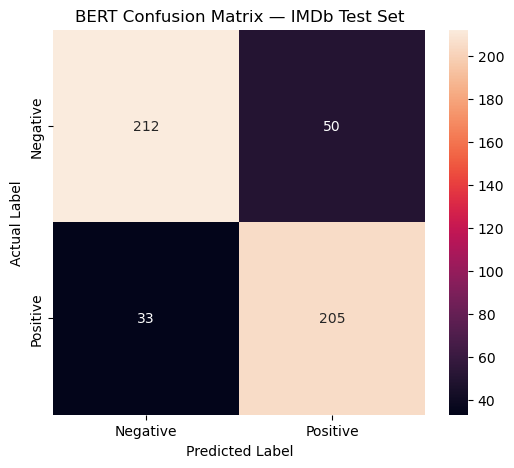

In [30]:
cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("BERT Confusion Matrix — IMDb Test Set")
plt.show()

## 20. Calculate Final Metrics

In [31]:
accuracy = accuracy_score(test_labels, test_predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels,
    test_predictions,
    average="binary",
    zero_division=0
)

final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [accuracy, precision, recall, f1]
})

final_metrics["Score"] = final_metrics["Score"].round(4)

display(final_metrics)

,Metric,Score
0,Accuracy,0.8340
1,Precision,0.8039
2,Recall,0.8613
3,F1 Score,0.8316


## 21. Test BERT on New Sentences

You can enter your own movie-review sentence and see whether BERT predicts it as positive or negative.

In [32]:
def predict_sentiment(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )

    device = model.device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0][predicted_class].item()

    sentiment = "POSITIVE" if predicted_class == 1 else "NEGATIVE"

    return sentiment, confidence


examples = [
    "This movie was absolutely fantastic. I loved every minute of it.",
    "The movie was boring, poorly written, and a complete waste of time.",
    "The acting was excellent and the story was very entertaining."
]

for text in examples:
    sentiment, confidence = predict_sentiment(text)
    print("Review:", text)
    print(f"Prediction: {sentiment} ({confidence:.2%})")
    print("-" * 80)

Review: This movie was absolutely fantastic. I loved every minute of it.
Prediction: POSITIVE (89.33%)
--------------------------------------------------------------------------------
Review: The movie was boring, poorly written, and a complete waste of time.
Prediction: NEGATIVE (89.49%)
--------------------------------------------------------------------------------
Review: The acting was excellent and the story was very entertaining.
Prediction: POSITIVE (90.15%)
--------------------------------------------------------------------------------


## 22. Interactive Prediction

Change `my_review` and run the cell to test your own review.

In [33]:
my_review = "The movie had a great story and amazing acting."

sentiment, confidence = predict_sentiment(my_review)

print("Review:", my_review)
print("Predicted Sentiment:", sentiment)
print(f"Confidence: {confidence:.2%}")

Review: The movie had a great story and amazing acting.
Predicted Sentiment: POSITIVE
Confidence: 91.57%


# Conclusion

### Objective
To perform sentiment analysis on IMDb movie reviews using a pretrained **BERT** model.

### Method
1. Loaded the IMDb movie review dataset.
2. Assigned `positive = 1` and `negative = 0`.
3. Split the training data into training and validation sets.
4. Used the BERT tokenizer to convert reviews into token IDs.
5. Loaded pretrained `bert-base-uncased`.
6. Fine-tuned BERT for binary sentiment classification.
7. Evaluated the model using Accuracy, Precision, Recall and F1-score.
8. Generated a confusion matrix.
9. Tested the trained model on new movie-review sentences.